In [1]:
import uproot
import pandas as pd
import numpy as np
import glob


In [2]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [28]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_Kspip_loose_v7_250122"
cm_elements = ["Kshp_13_had_4S_off_v1", "Kshp_13_had_4S_v3", "Kshp_23_had_4S_off_v1", "Kshp_23_had_4S_v1", "Kshp_23_had_5Sscan_10657_v1", "Kshp_23_had_5Sscan_10706_v1",\
               "Kshp_23_had_5Sscan_10751_v1", "Kshp_23_had_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_gg_K"
tree_name = "Ks_K"
file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [29]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [30]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,71609.000000,71609.000000,71609.000000,71609.000000,71609.000000
mean,1.903521,0.254836,0.471495,1.814369,-0.019285
std,0.097413,0.481957,0.436734,0.764901,0.999821
min,1.600023,-0.973173,-0.866684,0.404699,-1.000000
25%,1.868244,-0.129941,0.153772,1.264756,-1.000000
50%,1.958934,0.357627,0.620664,1.711492,-1.000000
75%,1.970221,0.663961,0.847738,2.249791,1.000000
max,2.099971,0.999923,0.970249,5.135494,1.000000


In [31]:
df_proc13 = df_proc13.query('Dp_M> 1.9 & Dp_M<2.03')


In [32]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,36686.000000,36686.000000,36686.000000,36686.000000,36686.000000
mean,1.969798,0.259587,0.468682,1.893563,-0.015156
std,0.014470,0.477858,0.434442,0.765881,0.999899
min,1.900020,-0.956637,-0.864233,0.404699,-1.000000
25%,1.965690,-0.117631,0.150653,1.342421,-1.000000
50%,1.969282,0.362805,0.616940,1.788799,-1.000000
75%,1.973413,0.664419,0.840587,2.330655,1.000000
max,2.029949,0.999923,0.965640,4.998510,1.000000


In [33]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [34]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250122"
cm_elements = ["MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1", "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1", "MCrd_Ks_mori_off_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_gg_K"
tree_name = "Ks_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [35]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [36]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,307782.000000,307782.000000,307782.000000,307782.000000,307782.000000
mean,1.904441,0.248596,0.474253,1.739764,-0.002079
std,0.101253,0.473523,0.431670,0.756092,0.999999
min,1.600001,-0.992705,-0.891978,0.400201,-1.000000
25%,1.868478,-0.124611,0.168180,1.183388,-1.000000
50%,1.963132,0.339368,0.617472,1.630647,-1.000000
75%,1.969755,0.650411,0.844320,2.170399,1.000000
max,2.099997,0.999930,0.976954,5.176636,1.000000


In [37]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.9 & Dp_M<2.03')


In [38]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,170905.000000,170905.000000,170905.000000,170905.000000,170905.000000
mean,1.968562,0.247046,0.463659,1.805681,0.000462
std,0.013353,0.470797,0.427647,0.752035,1.000003
min,1.900004,-0.985446,-0.889099,0.400201,-1.000000
25%,1.965453,-0.122192,0.158159,1.261138,-1.000000
50%,1.968628,0.332598,0.600803,1.699562,1.000000
75%,1.971845,0.646420,0.827976,2.233432,1.000000
max,2.029999,0.999930,0.976954,5.176636,1.000000


In [39]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [40]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


In [41]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


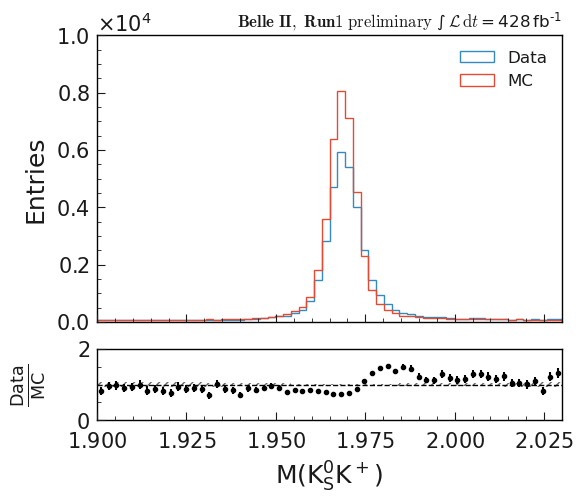

In [48]:
name = "Dp_M"
category = "category"
xlabel = r"$M(K_S^0 K^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.9,2.03)

h1 = make_hist(x1, bins=60, range=x_range, weights=1)
h2 = make_hist(x2, bins=60, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{ref_tree}_{name}.png", bbox_inches="tight")